In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [157]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

In [158]:
df=pd.read_csv("profit_analysis.csv")

In [159]:
df.head()

,RD_Spend,Administration,Marketing_Spend,State,Profit
0,165349.20,136897.80,471784.10,New York,192261.83
1,162597.70,151377.59,443898.53,California,191792.06
2,153441.51,101145.55,407934.54,Florida,191050.39
3,144372.41,118671.85,383199.62,New York,182901.99
4,142107.34,91391.77,366168.42,Florida,166187.94


In [160]:
df.values

array([[165349.2, 136897.8, 471784.1, 'New York', 192261.83],
       [162597.7, 151377.59, 443898.53, 'California', 191792.06],
       [153441.51, 101145.55, 407934.54, 'Florida', 191050.39],
       [144372.41, 118671.85, 383199.62, 'New York', 182901.99],
       [142107.34, 91391.77, 366168.42, 'Florida', 166187.94],
       [131876.9, 99814.71, 362861.36, 'New York', 156991.12],
       [134615.46, 147198.87, 127716.82, 'California', 156122.51],
       [130298.13, 145530.06, 323876.68, 'Florida', 155752.6],
       [120542.52, 148718.95, 311613.29, 'New York', 152211.77],
       [123334.88, 108679.17, 304981.62, 'California', 149759.96],
       [101913.08, 110594.11, 229160.95, 'Florida', 146121.95],
       [100671.96, 91790.61, 249744.55, 'California', 144259.4],
       [93863.75, 127320.38, 249839.44, 'Florida', 141585.52],
       [91992.39, 135495.07, 252664.93, 'California', 134307.35],
       [119943.24, 156547.42, 256512.92, 'Florida', 132602.65],
       [114523.61, 122616.84, 261

In [161]:
df.value_counts()           #count how many times values repeat

RD_Spend   Administration  Marketing_Spend  State       Profit   
0.00       116983.80       45173.06         California  14681.40     1
101913.08  110594.11       229160.95        Florida     146121.95    1
76253.86   113867.30       298664.47        California  118474.03    1
77044.01   99281.34        140574.81        New York    108552.04    1
78013.11   121597.55       264346.06        California  126992.93    1
78389.47   153773.43       299737.29        New York    111313.02    1
86419.70   153514.11       0.00             New York    122776.86    1
91749.16   114175.79       294919.57        Florida     124266.90    1
91992.39   135495.07       252664.93        California  134307.35    1
93863.75   127320.38       249839.44        Florida     141585.52    1
94657.16   145077.58       282574.31        New York    125370.37    1
100671.96  91790.61        249744.55        California  144259.40    1
114523.61  122616.84       261776.23        New York    129917.04    1
0.00       

In [162]:
df.tail()               #last 5 rows of data

,RD_Spend,Administration,Marketing_Spend,State,Profit
45,1000.23,124153.04,1903.93,New York,64926.08
46,1315.46,115816.21,297114.46,Florida,49490.75
47,0.00,135426.92,0.00,California,42559.73
48,542.05,51743.15,0.00,New York,35673.41
49,0.00,116983.80,45173.06,California,14681.40


In [163]:
df.shape                      #size of data

(50, 5)

In [164]:
df.columns

Index(['RD_Spend', 'Administration', 'Marketing_Spend', 'State', 'Profit'], dtype='object')

In [165]:
df.info()                       #data types

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RD_Spend         50 non-null     float64
 1   Administration   50 non-null     float64
 2   Marketing_Spend  50 non-null     float64
 3   State            50 non-null     object 
 4   Profit           50 non-null     float64
dtypes: float64(4), object(1)
memory usage: 2.1+ KB


In [166]:
df.describe()                  #numerical summary

,RD_Spend,Administration,Marketing_Spend,Profit
count,50.000000,50.000000,50.000000,50.000000
mean,73721.615600,121344.639600,211025.097800,112012.639200
std,45902.256482,28017.802755,122290.310726,40306.180338
min,0.000000,51283.140000,0.000000,14681.400000
25%,39936.370000,103730.875000,129300.132500,90138.902500
50%,73051.080000,122699.795000,212716.240000,107978.190000
75%,101602.800000,144842.180000,299469.085000,139765.977500
max,165349.200000,182645.560000,471784.100000,192261.830000


In [167]:
df.duplicated().sum()          #checking duliplicates is there or not

np.int64(0)

In [29]:
df.dtypes

RD_Spend           float64
Administration     float64
Marketing_Spend    float64
State               object
Profit             float64
dtype: object

In [168]:
df.sample()

,RD_Spend,Administration,Marketing_Spend,State,Profit
12,93863.75,127320.38,249839.44,Florida,141585.52


In [169]:
df["Profit"]           #for particular column

0     192261.83
1     191792.06
2     191050.39
3     182901.99
4     166187.94
5     156991.12
6     156122.51
7     155752.60
8     152211.77
9     149759.96
10    146121.95
11    144259.40
12    141585.52
13    134307.35
14    132602.65
15    129917.04
16    126992.93
17    125370.37
18    124266.90
19    122776.86
20    118474.03
21    111313.02
22    110352.25
23    108733.99
24    108552.04
25    107404.34
26    105733.54
27    105008.31
28    103282.38
29    101004.64
30     99937.59
31     97483.56
32     97427.84
33     96778.92
34     96712.80
35     96479.51
36     90708.19
37     89949.14
38     81229.06
39     81005.76
40     78239.91
41     77798.83
42     71498.49
43     69758.98
44     65200.33
45     64926.08
46     49490.75
47     42559.73
48     35673.41
49     14681.40
Name: Profit, dtype: float64

In [170]:
df.iloc[0:5]                   #select rows

,RD_Spend,Administration,Marketing_Spend,State,Profit
0,165349.20,136897.80,471784.10,New York,192261.83
1,162597.70,151377.59,443898.53,California,191792.06
2,153441.51,101145.55,407934.54,Florida,191050.39
3,144372.41,118671.85,383199.62,New York,182901.99
4,142107.34,91391.77,366168.42,Florida,166187.94


In [171]:
df.isnull().sum()

RD_Spend           0
Administration     0
Marketing_Spend    0
State              0
Profit             0
dtype: int64

In [172]:
df.drop_duplicates()

,RD_Spend,Administration,Marketing_Spend,State,Profit
0,165349.20,136897.80,471784.10,New York,192261.83
1,162597.70,151377.59,443898.53,California,191792.06
2,153441.51,101145.55,407934.54,Florida,191050.39
3,144372.41,118671.85,383199.62,New York,182901.99
4,142107.34,91391.77,366168.42,Florida,166187.94
5,131876.90,99814.71,362861.36,New York,156991.12
6,134615.46,147198.87,127716.82,California,156122.51
7,130298.13,145530.06,323876.68,Florida,155752.60
8,120542.52,148718.95,311613.29,New York,152211.77
9,123334.88,108679.17,304981.62,California,149759.96


In [173]:
df.sort_values("Profit", ascending=True)         #ascending

,RD_Spend,Administration,Marketing_Spend,State,Profit
49,0.00,116983.80,45173.06,California,14681.40
48,542.05,51743.15,0.00,New York,35673.41
47,0.00,135426.92,0.00,California,42559.73
46,1315.46,115816.21,297114.46,Florida,49490.75
45,1000.23,124153.04,1903.93,New York,64926.08
44,22177.74,154806.14,28334.72,California,65200.33
43,15505.73,127382.30,35534.17,New York,69758.98
42,23640.93,96189.63,148001.11,California,71498.49
41,27892.92,84710.77,164470.71,Florida,77798.83
40,28754.33,118546.05,172795.67,California,78239.91


In [174]:
df.sort_values("Profit",ascending=False)

,RD_Spend,Administration,Marketing_Spend,State,Profit
0,165349.20,136897.80,471784.10,New York,192261.83
1,162597.70,151377.59,443898.53,California,191792.06
2,153441.51,101145.55,407934.54,Florida,191050.39
3,144372.41,118671.85,383199.62,New York,182901.99
4,142107.34,91391.77,366168.42,Florida,166187.94
5,131876.90,99814.71,362861.36,New York,156991.12
6,134615.46,147198.87,127716.82,California,156122.51
7,130298.13,145530.06,323876.68,Florida,155752.60
8,120542.52,148718.95,311613.29,New York,152211.77
9,123334.88,108679.17,304981.62,California,149759.96


In [175]:
df[df["Profit"]>150000]

,RD_Spend,Administration,Marketing_Spend,State,Profit
0,165349.20,136897.80,471784.10,New York,192261.83
1,162597.70,151377.59,443898.53,California,191792.06
2,153441.51,101145.55,407934.54,Florida,191050.39
3,144372.41,118671.85,383199.62,New York,182901.99
4,142107.34,91391.77,366168.42,Florida,166187.94
5,131876.90,99814.71,362861.36,New York,156991.12
6,134615.46,147198.87,127716.82,California,156122.51
7,130298.13,145530.06,323876.68,Florida,155752.60
8,120542.52,148718.95,311613.29,New York,152211.77


In [176]:
df[0:3]

,RD_Spend,Administration,Marketing_Spend,State,Profit
0,165349.20,136897.80,471784.10,New York,192261.83
1,162597.70,151377.59,443898.53,California,191792.06
2,153441.51,101145.55,407934.54,Florida,191050.39


In [177]:
df.iloc[3]

RD_Spend           144372.41
Administration     118671.85
Marketing_Spend    383199.62
State               New York
Profit             182901.99
Name: 3, dtype: object

In [178]:
df[(df["Profit"]>155752.60) | (df["Profit"]>182901.99)]

,RD_Spend,Administration,Marketing_Spend,State,Profit
0,165349.20,136897.80,471784.10,New York,192261.83
1,162597.70,151377.59,443898.53,California,191792.06
2,153441.51,101145.55,407934.54,Florida,191050.39
3,144372.41,118671.85,383199.62,New York,182901.99
4,142107.34,91391.77,366168.42,Florida,166187.94
5,131876.90,99814.71,362861.36,New York,156991.12
6,134615.46,147198.87,127716.82,California,156122.51


In [179]:
df[(df["Profit"]>182901.99)]

,RD_Spend,Administration,Marketing_Spend,State,Profit
0,165349.20,136897.80,471784.10,New York,192261.83
1,162597.70,151377.59,443898.53,California,191792.06
2,153441.51,101145.55,407934.54,Florida,191050.39


In [180]:
df

,RD_Spend,Administration,Marketing_Spend,State,Profit
0,165349.20,136897.80,471784.10,New York,192261.83
1,162597.70,151377.59,443898.53,California,191792.06
2,153441.51,101145.55,407934.54,Florida,191050.39
3,144372.41,118671.85,383199.62,New York,182901.99
4,142107.34,91391.77,366168.42,Florida,166187.94
5,131876.90,99814.71,362861.36,New York,156991.12
6,134615.46,147198.87,127716.82,California,156122.51
7,130298.13,145530.06,323876.68,Florida,155752.60
8,120542.52,148718.95,311613.29,New York,152211.77
9,123334.88,108679.17,304981.62,California,149759.96


In [181]:
df.loc[1:3,["Profit"]]

,Profit
1,191792.06
2,191050.39
3,182901.99


In [182]:
df.iloc[1:6,:3]

,RD_Spend,Administration,Marketing_Spend
1,162597.70,151377.59,443898.53
2,153441.51,101145.55,407934.54
3,144372.41,118671.85,383199.62
4,142107.34,91391.77,366168.42
5,131876.90,99814.71,362861.36


In [85]:
df.shape

(50, 5)

In [183]:
df["State"].unique()

array(['New York', 'California', 'Florida'], dtype=object)

In [184]:
df["State"].value_counts()

State
New York      17
California    17
Florida       16
Name: count, dtype: int64

In [185]:
df["More_Profit"]=df["Profit"]*10

In [186]:
df

,RD_Spend,Administration,Marketing_Spend,State,Profit,More_Profit
0,165349.20,136897.80,471784.10,New York,192261.83,1922618.3
1,162597.70,151377.59,443898.53,California,191792.06,1917920.6
2,153441.51,101145.55,407934.54,Florida,191050.39,1910503.9
3,144372.41,118671.85,383199.62,New York,182901.99,1829019.9
4,142107.34,91391.77,366168.42,Florida,166187.94,1661879.4
5,131876.90,99814.71,362861.36,New York,156991.12,1569911.2
6,134615.46,147198.87,127716.82,California,156122.51,1561225.1
7,130298.13,145530.06,323876.68,Florida,155752.60,1557526.0
8,120542.52,148718.95,311613.29,New York,152211.77,1522117.7
9,123334.88,108679.17,304981.62,California,149759.96,1497599.6


In [187]:
df.drop("More_Profit",axis=1,inplace=True)

In [188]:
df

,RD_Spend,Administration,Marketing_Spend,State,Profit
0,165349.20,136897.80,471784.10,New York,192261.83
1,162597.70,151377.59,443898.53,California,191792.06
2,153441.51,101145.55,407934.54,Florida,191050.39
3,144372.41,118671.85,383199.62,New York,182901.99
4,142107.34,91391.77,366168.42,Florida,166187.94
5,131876.90,99814.71,362861.36,New York,156991.12
6,134615.46,147198.87,127716.82,California,156122.51
7,130298.13,145530.06,323876.68,Florida,155752.60
8,120542.52,148718.95,311613.29,New York,152211.77
9,123334.88,108679.17,304981.62,California,149759.96


In [189]:
df.isnull().sum()

RD_Spend           0
Administration     0
Marketing_Spend    0
State              0
Profit             0
dtype: int64

In [190]:
df.dropna()

,RD_Spend,Administration,Marketing_Spend,State,Profit
0,165349.20,136897.80,471784.10,New York,192261.83
1,162597.70,151377.59,443898.53,California,191792.06
2,153441.51,101145.55,407934.54,Florida,191050.39
3,144372.41,118671.85,383199.62,New York,182901.99
4,142107.34,91391.77,366168.42,Florida,166187.94
5,131876.90,99814.71,362861.36,New York,156991.12
6,134615.46,147198.87,127716.82,California,156122.51
7,130298.13,145530.06,323876.68,Florida,155752.60
8,120542.52,148718.95,311613.29,New York,152211.77
9,123334.88,108679.17,304981.62,California,149759.96


In [191]:
df[df.duplicated()]

,RD_Spend,Administration,Marketing_Spend,State,Profit


In [192]:
df["RD_Spend"].fillna(df["RD_Spend"].mean())

0     165349.20
1     162597.70
2     153441.51
3     144372.41
4     142107.34
5     131876.90
6     134615.46
7     130298.13
8     120542.52
9     123334.88
10    101913.08
11    100671.96
12     93863.75
13     91992.39
14    119943.24
15    114523.61
16     78013.11
17     94657.16
18     91749.16
19     86419.70
20     76253.86
21     78389.47
22     73994.56
23     67532.53
24     77044.01
25     64664.71
26     75328.87
27     72107.60
28     66051.52
29     65605.48
30     61994.48
31     61136.38
32     63408.86
33     55493.95
34     46426.07
35     46014.02
36     28663.76
37     44069.95
38     20229.59
39     38558.51
40     28754.33
41     27892.92
42     23640.93
43     15505.73
44     22177.74
45      1000.23
46      1315.46
47         0.00
48       542.05
49         0.00
Name: RD_Spend, dtype: float64

In [193]:
df["Profit"].duplicated().sum()

np.int64(0)

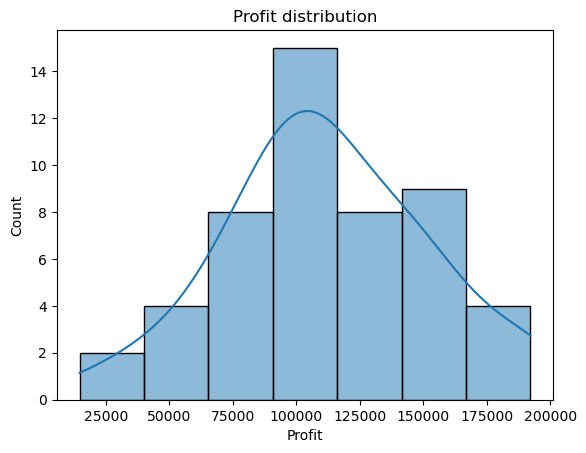

In [194]:
sns.histplot(df["Profit"],kde=True)
plt.title("Profit distribution")
plt.show()

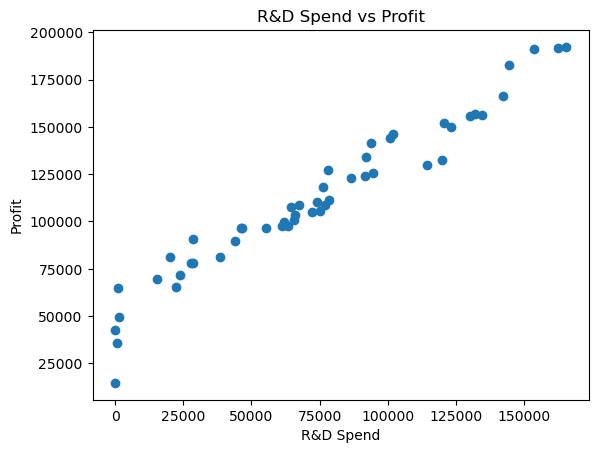

In [195]:
plt.scatter(df["RD_Spend"], df["Profit"])

plt.xlabel("R&D Spend")
plt.ylabel("Profit")
plt.title("R&D Spend vs Profit")

plt.show()

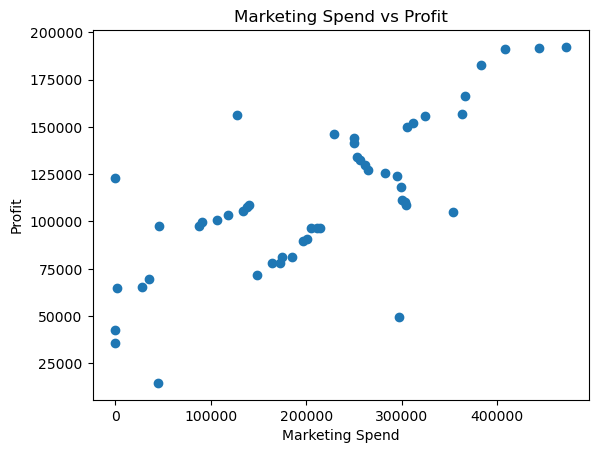

In [196]:
plt.scatter(df["Marketing_Spend"], df["Profit"])

plt.xlabel("Marketing Spend")
plt.ylabel("Profit")
plt.title("Marketing Spend vs Profit")

plt.show()

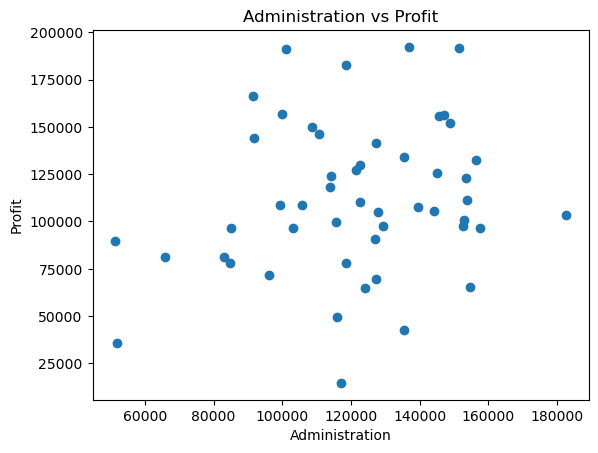

In [197]:
plt.scatter(df["Administration"], df["Profit"])

plt.xlabel("Administration")
plt.ylabel("Profit")
plt.title("Administration vs Profit")

plt.show()

In [198]:
df.corr(numeric_only=True)

,RD_Spend,Administration,Marketing_Spend,Profit
RD_Spend,1.000000,0.241955,0.724248,0.972900
Administration,0.241955,1.000000,-0.032154,0.200717
Marketing_Spend,0.724248,-0.032154,1.000000,0.747766
Profit,0.972900,0.200717,0.747766,1.000000


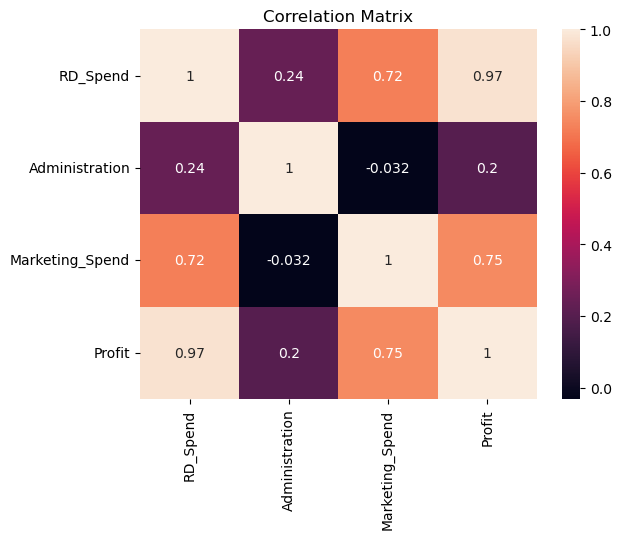

In [199]:
sns.heatmap(df.corr(numeric_only=True),annot=True)
plt.title("Correlation Matrix")
plt.show()

In [200]:
X = df[["RD_Spend", "Administration", "Marketing_Spend"]]#RD_Spend	Administration	Marketing_Spend
y = df["Profit"]

In [201]:
X_train, X_test, y_train, y_test = train_test_split(
X,y,
    test_size=0.2,
    random_state=42
)

In [202]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [203]:
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [204]:
y_pred = model.predict(X_test)

In [205]:
y_test

13    134307.35
39     81005.76
30     99937.59
45     64926.08
17    125370.37
48     35673.41
26    105733.54
25    107404.34
32     97427.84
19    122776.86
Name: Profit, dtype: float64

In [216]:
y_pred

array([126703.02716461,  84894.75081556,  98893.41815974,  46501.70815036,
       129128.39734381,  50992.69486261, 109016.5536578 , 100878.4641454 ,
        97700.59638629, 113106.15292226])

In [217]:
comparison = pd.DataFrame({"Actual Profit": y_test,"Predicted Profit": y_pred})
comparison

,Actual Profit,Predicted Profit
13,134307.35,126703.027165
39,81005.76,84894.750816
30,99937.59,98893.418160
45,64926.08,46501.708150
17,125370.37,129128.397344
48,35673.41,50992.694863
26,105733.54,109016.553658
25,107404.34,100878.464145
32,97427.84,97700.596386
19,122776.86,113106.152922


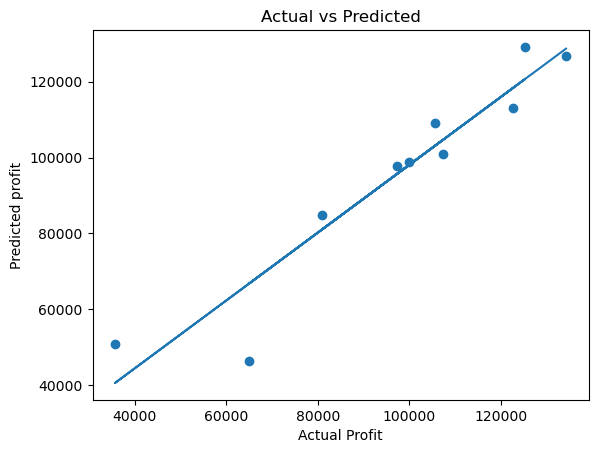

In [218]:
plt.scatter(y_test,y_pred)
m,b=np.polyfit(y_test,y_pred,1)
plt.plot(y_test,m*y_test+b)
plt.xlabel("Actual Profit")
plt.ylabel("Predicted profit")
plt.title("Actual vs Predicted")
plt.show()


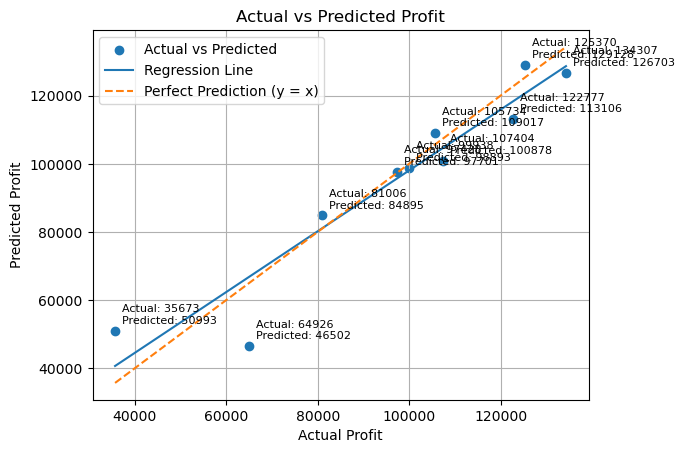

In [219]:
import numpy as np
import matplotlib.pyplot as plt

# Scatter plot
plt.scatter(y_test, y_pred, label="Actual vs Predicted")

# Add Actual and Predicted values for each point
for actual, predicted in zip(y_test, y_pred):
    plt.annotate(
        f"Actual: {actual:.0f}\nPredicted: {predicted:.0f}",
        (actual, predicted),
        xytext=(5, 5),
        textcoords="offset points",
        fontsize=8
    )

# Regression / best-fit line
m, b = np.polyfit(y_test, y_pred, 1)

x_line = np.linspace(y_test.min(), y_test.max(), 100)
y_line = m * x_line + b

plt.plot(x_line, y_line, label="Regression Line")

# Perfect prediction line
min_value = min(y_test.min(), y_pred.min())
max_value = max(y_test.max(), y_pred.max())

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--",
    label="Perfect Prediction (y = x)"
)

# Labels
plt.xlabel("Actual Profit")
plt.ylabel("Predicted Profit")
plt.title("Actual vs Predicted Profit")

plt.legend()
plt.grid(True)

plt.show()

In [221]:
from sklearn.metrics import mean_absolute_error

mae = mean_absolute_error(y_test, y_pred)

print("MAE:", mae)

MAE: 6979.152252370399


In [222]:
from sklearn.metrics import mean_squared_error
mse = mean_squared_error(y_test, y_pred)

rmse = np.sqrt(mse)

print("RMSE:", rmse)

RMSE: 8995.905803361413


In [223]:
from sklearn.metrics import r2_score

r2 = r2_score(y_test, y_pred)

print("R²:", r2)

R²: 0.9000653083037321


In [224]:
mse = mean_squared_error(y_test, y_pred)
print("MSE:",mse)

MSE: 80926321.22295156


In [225]:
X = df.drop("Profit", axis=1)

In [226]:
X = df[["RD_Spend", "Administration", "Marketing_Spend"]]

In [227]:
new_data1 = pd.DataFrame([{
    "RD_Spend":21892.92 ,
    "Administration": 81910.77,
    "Marketing_Spend": 164270.7
}])
new_data2 = pd.DataFrame([{
    "RD_Spend": 23940.93,
    "Administration": 96489.63,
    "Marketing_Spend": 137001.1
}])

In [228]:
prediction1 = model.predict(new_data1)
prediction1

array([71236.89079079])

In [230]:
prediction2 = model.predict(new_data2)
prediction2

array([71040.76440737])